## Projeto CardioIA - Visão Computacional (Fase 4)
### Parte 1: Pré-processamento e Organização das Imagens
### Parte 2: Classificação de Imagens Médicas com CNN e Transfer Learning

### Importação das Bibliotecas

In [2]:
import os
import shutil
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

### Configuração dos Caminhos do Dataset

In [3]:
# Definição dos caminhos locais com base na estrutura de arquivos ZIP
BASE_DIR = r"C:\Users\Fran\Nova pasta\fiap-fase4\dataset_estruturado"

### Carregamento dos Datasets via TensorFlow API

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Carregando os subconjuntos de imagens do diretório estruturado...")

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
print(f"Classes detectadas: {class_names}\n")

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'validation'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'test'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

Carregando os subconjuntos de imagens do diretório estruturado...
Found 2620 files belonging to 3 classes.
Classes detectadas: ['Cardiomegalia', 'Infiltrado', 'Saudavel']

Found 561 files belonging to 3 classes.
Found 564 files belonging to 3 classes.


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Performance otimizada com tf.data.AUTOTUNE (Prefetching ativo).")

Performance otimizada com tf.data.AUTOTUNE (Prefetching ativo).


### Inspeção Visual das Imagens Processadas

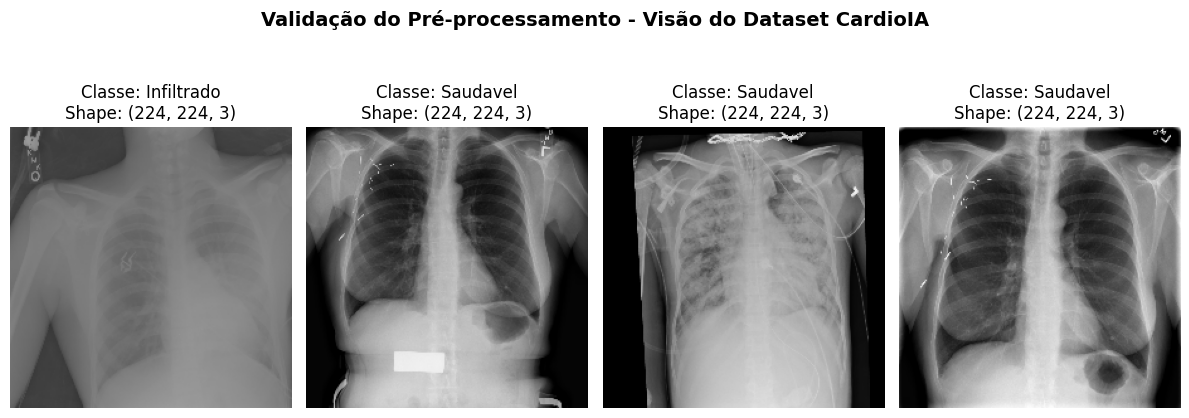

Valor de Pixel Máximo: 255.0 | Mínimo: 0.0


In [6]:
for images_batch, labels_batch in train_ds.take(1):
    plt.figure(figsize=(12, 5))
    for i in range(min(4, len(images_batch))):
        plt.subplot(1, 4, i + 1)
        plt.imshow(images_batch[i].numpy().astype("uint8"))
        label_idx = np.argmax(labels_batch[i])
        plt.title(f"Classe: {class_names[label_idx]}\nShape: {images_batch[i].shape}")
        plt.axis('off')

    plt.suptitle("Validação do Pré-processamento - Visão do Dataset CardioIA", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
    print(f"Valor de Pixel Máximo: {images_batch.numpy().max()} | Mínimo: {images_batch.numpy().min()}")

## PARTE 2 - Classificação de Imagens Médicas com CNN
### Abordagem 1: Arquitetura CNN Desenvolvida do Zero

### Cálculo de Pesos de Classe e Definição da CNN do Zero

In [7]:
# Cálculo automático de pesos para combater o desbalanceamento clínico
train_labels = np.concatenate([y for x, y in train_ds], axis=0)
train_labels_indices = np.argmax(train_labels, axis=1)

classes = np.unique(train_labels_indices)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_labels_indices)
class_weight_dict = dict(zip(classes, weights))

print(f"Pesos de classe: {class_weight_dict}")

# Data Augmentation focado em variações de Raio-X
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15), # Rotação um pouco maior
    layers.RandomZoom(0.15),     # Zoom para simular corações de tamanhos diferentes
    layers.RandomContrast(0.15)  # Altera o contraste (essencial para Raio-X com opacidade)
])

# Construção da Rede Convolucional Multiclasse do Zero
model_do_zero = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255), # Normalização dos pixels [0, 1]
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax') # Ajustado para 3 neurônios e Softmax
])

model_do_zero.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Ajustado para multiclasse
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model_do_zero.summary()

Pesos de classe: {np.int64(0): np.float64(6.374695863746958), np.int64(1): np.float64(1.5707434052757794), np.int64(2): np.float64(0.45320878740702303)}


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
EPOCHS = 10  

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_zero = model_do_zero.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)
print("Treinamento concluído!")

Epoch 1/10
12/82 ━━━━━━━━━━━━━━━━━━━━ 1:38 1s/step - accuracy: 0.3651 - loss: 2.0175 - precision: 0.5265 - recall: 0.2036

KeyboardInterrupt: 

### Avaliação Estatística e Matriz de Confusão

18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 441ms/step


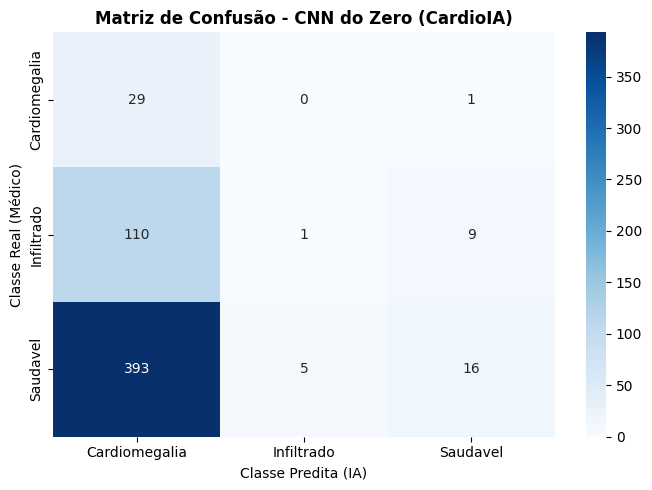


 --- RELATÓRIO DE MÉTRICAS ---
               precision    recall  f1-score   support

Cardiomegalia       0.05      0.97      0.10        30
   Infiltrado       0.17      0.01      0.02       120
     Saudavel       0.62      0.04      0.07       414

     accuracy                           0.08       564
    macro avg       0.28      0.34      0.06       564
 weighted avg       0.49      0.08      0.06       564



In [ ]:
predictions_zero = model_do_zero.predict(test_ds, verbose=1)
y_pred_zero = np.argmax(predictions_zero, axis=1)

# Extrai o gabarito real do conjunto de teste oculto
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_indices = np.argmax(y_true, axis=1)

# Matriz de Confusão
cm_zero = confusion_matrix(y_true_indices, y_pred_zero)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_zero, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - CNN do Zero (CardioIA)', fontsize=12, weight='bold')
plt.ylabel('Classe Real (Médico)')
plt.xlabel('Classe Predita (IA)')
plt.tight_layout()
plt.show()

print("\n --- RELATÓRIO DE MÉTRICAS ---")
print(classification_report(y_true_indices, y_pred_zero, target_names=class_names))

### Curvas de Loss e Acurácia

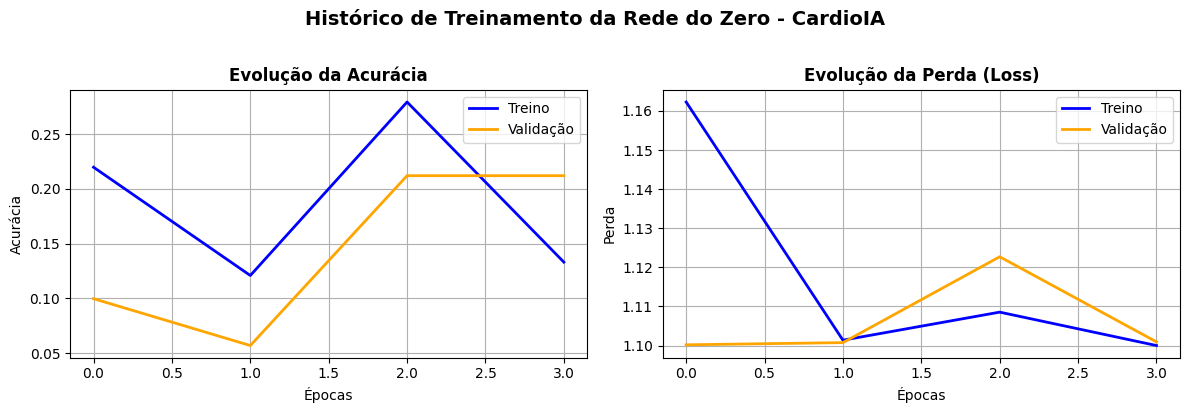

In [ ]:
plt.figure(figsize=(12, 4))

# Evolução da Acurácia
plt.subplot(1, 2, 1)
plt.plot(history_zero.history['accuracy'], label='Treino', color='blue', linewidth=2)
plt.plot(history_zero.history['val_accuracy'], label='Validação', color='orange', linewidth=2)
plt.title('Evolução da Acurácia', weight='bold')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

# Evolução da Perda
plt.subplot(1, 2, 2)
plt.plot(history_zero.history['loss'], label='Treino', color='blue', linewidth=2)
plt.plot(history_zero.history['val_loss'], label='Validação', color='orange', linewidth=2)
plt.title('Evolução da Perda (Loss)', weight='bold')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.grid(True)

plt.suptitle("Histórico de Treinamento da Rede do Zero - CardioIA", fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Abordagem 2: Aprendizado por Transferência (Transfer Learning) com VGG16

### Construção do Modelo Customizado VGG16

In [ ]:
# 1. Carregar a VGG16 pré-treinada excluindo o topo original classificatório
base_model = VGG16(
    weights='imagenet',          
    include_top=False,           
    input_shape=(224, 224, 3)    
)

# 2. Congelamento dos pesos do bloco extrator de recursos
base_model.trainable = False

# 3. Construção da Rede com Camada de Entrada e Pré-processador nativo da VGG16
model_vgg = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    # Normalização nativa exigida pela arquitetura VGG16:
    layers.Lambda(tf.keras.applications.vgg16.preprocess_input),
    
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax') # Ajustado para 3 saídas com Softmax
])

model_vgg.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-5), 
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model_vgg.summary()
print("\nModelo VGG16 acoplado e pronto para Transfer Learning!")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


Modelo VGG16 acoplado e pronto para Transfer Learning!


### Treinamento da VGG16 Customizada

In [ ]:
# 1. Libera o modelo base para treinamento
base_model.trainable = True

# 2. Congele todas as camadas, EXCETO as últimas 4 (o bloco convolucional final)
for layer in base_model.layers[:-4]:
    layer.trainable = False

print("🔓 Fine-Tuning ativado para o Bloco 5 da VGG16!")

🔓 Fine-Tuning ativado para o Bloco 5 da VGG16!


In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,             # Dá mais tempo para o modelo se recuperar de oscilações
    restore_best_weights=True
)

history_vgg = model_vgg.fit(
    train_ds,
    epochs=20,              # Aumentado para dar margem ao Fine-Tuning
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
72/82 ━━━━━━━━━━━━━━━━━━━━ 1:19 8s/step - accuracy: 0.3341 - loss: 2.4136 - precision_1: 0.3398 - recall_1: 0.2901

KeyboardInterrupt: 

### Avaliação Estatística e Matriz de Confusão (VGG16)

Computando predições para o conjunto de teste com a VGG16...
18/18 ━━━━━━━━━━━━━━━━━━━━ 123s 6s/step


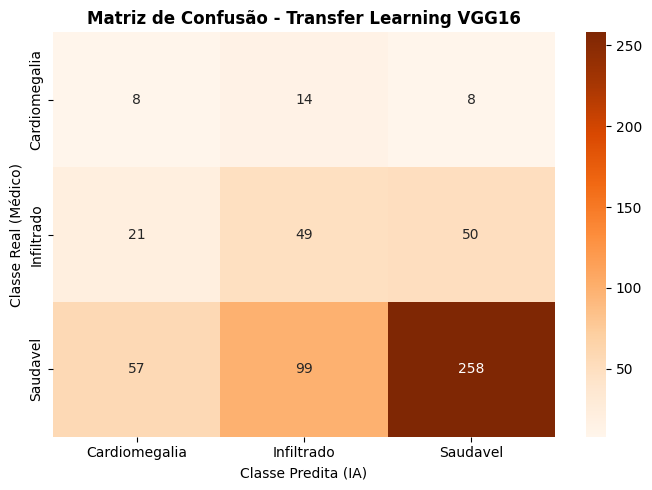


 --- RELATÓRIO DE MÉTRICAS (VGG16) ---
               precision    recall  f1-score   support

Cardiomegalia       0.09      0.27      0.14        30
   Infiltrado       0.30      0.41      0.35       120
     Saudavel       0.82      0.62      0.71       414

     accuracy                           0.56       564
    macro avg       0.40      0.43      0.40       564
 weighted avg       0.67      0.56      0.60       564



In [ ]:
print("Computando predições para o conjunto de teste com a VGG16...")
predictions_vgg = model_vgg.predict(test_ds, verbose=1)
y_pred_vgg = np.argmax(predictions_vgg, axis=1)

# Matriz de Confusão
cm_vgg = confusion_matrix(y_true_indices, y_pred_vgg)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - Transfer Learning VGG16', fontsize=12, weight='bold')
plt.ylabel('Classe Real (Médico)')
plt.xlabel('Classe Predita (IA)')
plt.tight_layout()
plt.show()

print("\n --- RELATÓRIO DE MÉTRICAS (VGG16) ---")
print(classification_report(y_true_indices, y_pred_vgg, target_names=class_names))

In [9]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import layers, models
import tensorflow as tf

print("🏗️ 1. Carregando a arquitetura da ResNet50V2 pré-treinada...")

# 1. Carrega a base da ResNet50V2 (excluindo o topo de 1000 classes do ImageNet)
base_model_resnet = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# 2. Desbloqueia para Fine-Tuning (Liberando o último bloco residual para aprender Raio-X)
base_model_resnet.trainable = True
for layer in base_model_resnet.layers[:-15]: # Congele tudo, menos as últimas 15 camadas brutas
    layer.trainable = False

print("🔓 Fine-Tuning ativado para as camadas finais da ResNet!")

# 3. Montando a nova estrutura do CardioIA acoplada à ResNet
model_resnet = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation, # Usa o data augmentation que definimos antes
    
    # Normalização nativa exigida pela arquitetura ResNet V2:
    layers.Lambda(tf.keras.applications.resnet_v2.preprocess_input),
    
    base_model_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(), # Estabiliza os gradientes para evitar o travamento em 0.4
    layers.Dropout(0.4),
    layers.Dense(3, activation='softmax') # Nossas 3 classes clínicas
])

# 4. Compilando o modelo com Adam lento (essencial para fine-tuning estável)
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("⚖️ 2. Aplicando Pesos Manuais de Penalização para combater desbalanceamento...")
# Multiplica a importância da Cardiomegalia por 5 para forçar o aprendizado
class_weight_dict = {
    0: 5.0,  # Classe: Cardiomegalia
    1: 2.0,  # Classe: Infiltrado
    2: 0.5   # Classe: Saudavel
}

# 5. Configuração do Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("🏋️ 3. Iniciando o treinamento por 20 épocas...\n")
# Executa as épocas de treino utilizando a variável que acabou de ser criada acima
history_resnet = model_resnet.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

print("\n🏁 Treinamento da ResNet50V2 finalizado com sucesso!")

🏗️ 1. Carregando a arquitetura da ResNet50V2 pré-treinada...
🔓 Fine-Tuning ativado para as camadas finais da ResNet!

⚖️ 2. Aplicando Pesos Manuais de Penalização para combater desbalanceamento...
🏋️ 3. Iniciando o treinamento por 20 épocas...

Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 319s 4s/step - accuracy: 0.3336 - loss: 1.9903 - precision_1: 0.3348 - recall_1: 0.2939 - val_accuracy: 0.3743 - val_loss: 1.1887 - val_precision_1: 0.3600 - val_recall_1: 0.1765
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 430s 5s/step - accuracy: 0.3424 - loss: 1.8467 - precision_1: 0.3426 - recall_1: 0.2969 - val_accuracy: 0.3922 - val_loss: 1.2126 - val_precision_1: 0.3959 - val_recall_1: 0.2406
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 404s 5s/step - accuracy: 0.3760 - loss: 1.6964 - precision_1: 0.3778 - recall_1: 0.3317 - val_accuracy: 0.4332 - val_loss: 1.2052 - val_precision_1: 0.4578 - val_recall_1: 0.3191
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 423s 5s/step - accuracy: 0.3737 - loss: 1.6704 - precision_1: 0.37

In [ ]:
# Force os pesos manualmente no seu script antigo para obrigar o modelo a focar:
# Damos um peso absurdamente maior para a classe 0 (Cardiomegalia) e classe 1 (Infiltrado)
class_weight_dict = {
    0: 5.0,  # Multiplica por 5 a importância da Cardiomegalia
    1: 2.0,  # Multiplica por 2 a importância do Infiltrado
    2: 0.5   # Reduz a importância da classe Saudável (já que tem demais)
}

print(f"⚖️ Pesos hiper-balanceados manualmente: {class_weight_dict}")

⚖️ Pesos hiper-balanceados manualmente: {0: 5.0, 1: 2.0, 2: 0.5}
